In [1]:
print("Hello")

Hello


In [2]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

In [3]:
DATA_PATH = Path("data/fastf1_race_level_2018_2025.csv")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

In [5]:
race_data = pd.read_csv(DATA_PATH)

print("Dataset shape:", race_data.shape)
display(race_data.head())
print(race_data.columns.tolist())


Dataset shape: (800, 16)


,season,round,event_date,event_name,country,location,event_format,driver,driver_number,team,grid_position,finish_position,points,status,winner,podium
0,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,VET,5,Ferrari,3.0,1.0,25.0,Finished,1,1
1,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,HAM,44,Mercedes,1.0,2.0,18.0,Finished,0,1
2,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,RAI,7,Ferrari,2.0,3.0,15.0,Finished,0,1
3,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,RIC,3,Red Bull,8.0,4.0,12.0,Finished,0,0
4,2018,1,2018-03-25,Australian Grand Prix,Australia,Melbourne,conventional,ALO,14,McLaren,10.0,5.0,10.0,Finished,0,0


['season', 'round', 'event_date', 'event_name', 'country', 'location', 'event_format', 'driver', 'driver_number', 'team', 'grid_position', 'finish_position', 'points', 'status', 'winner', 'podium']


In [6]:
race_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           800 non-null    int64  
 1   round            800 non-null    int64  
 2   event_date       800 non-null    object 
 3   event_name       800 non-null    object 
 4   country          800 non-null    object 
 5   location         800 non-null    object 
 6   event_format     800 non-null    object 
 7   driver           800 non-null    object 
 8   driver_number    800 non-null    int64  
 9   team             800 non-null    object 
 10  grid_position    800 non-null    float64
 11  finish_position  800 non-null    float64
 12  points           800 non-null    float64
 13  status           800 non-null    object 
 14  winner           800 non-null    int64  
 15  podium           800 non-null    int64  
dtypes: float64(3), int64(5), object(8)
memory usage: 100.1+ KB


In [7]:
data = race_data.copy()

data["grid_position"] = pd.to_numeric(data["grid_position"], errors="coerce")
data["finish_position"] = pd.to_numeric(data["finish_position"], errors="coerce")
data["points"] = pd.to_numeric(data["points"], errors="coerce").fillna(0)
data["podium"] = pd.to_numeric(data["podium"], errors="coerce").fillna(0).astype(int)
data["winner"] = pd.to_numeric(data["winner"], errors="coerce").fillna(0).astype(int)

In [ ]:
# Lower grid and finish positions are better, so missing values are treated as back-of-field values.
data["grid_position"] = data["grid_position"].fillna(data["grid_position"].max())
data["finish_position"] = data["finish_position"].fillna(data["finish_position"].max())

# Practical proxy for overtakes/positions gained during a race.
data["estimated_overtakes"] = (data["grid_position"] - data["finish_position"]).clip(lower=0)
data["finished_in_points"] = (data["points"] > 0).astype(int)

In [9]:
display(
    data[[
        "season", "round", "driver", "team", "grid_position",
        "finish_position", "points", "podium", "estimated_overtakes"
    ]].head(10)
)

,season,round,driver,team,grid_position,finish_position,points,podium,estimated_overtakes
0,2018,1,VET,Ferrari,3.0,1.0,25.0,1,2.0
1,2018,1,HAM,Mercedes,1.0,2.0,18.0,1,0.0
2,2018,1,RAI,Ferrari,2.0,3.0,15.0,1,0.0
3,2018,1,RIC,Red Bull,8.0,4.0,12.0,0,4.0
4,2018,1,ALO,McLaren,10.0,5.0,10.0,0,5.0
5,2018,1,VER,Red Bull,4.0,6.0,8.0,0,0.0
6,2018,1,HUL,Renault,7.0,7.0,6.0,0,0.0
7,2018,1,BOT,Mercedes,15.0,8.0,4.0,0,7.0
8,2018,1,VAN,McLaren,11.0,9.0,2.0,0,2.0
9,2018,1,SAI,Renault,9.0,10.0,1.0,0,0.0


In [10]:
driver_season = (
    data.groupby(["season", "driver"], as_index=False)
    .agg(
        team=("team", lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[-1]),
        races=("round", "nunique"),
        total_points=("points", "sum"),
        avg_grid_position=("grid_position", "mean"),
        avg_finish_position=("finish_position", "mean"),
        podiums=("podium", "sum"),
        wins=("winner", "sum"),
        points_finishes=("finished_in_points", "sum"),
        estimated_overtakes=("estimated_overtakes", "sum"),
    )
)

In [11]:
driver_season["points_per_race"] = driver_season["total_points"] / driver_season["races"]
driver_season["podium_rate"] = driver_season["podiums"] / driver_season["races"]
driver_season["points_finish_rate"] = driver_season["points_finishes"] / driver_season["races"]
driver_season["overtakes_per_race"] = driver_season["estimated_overtakes"] / driver_season["races"]

In [ ]:
# Convert qualifying/grid performance into a high-is-good score.
driver_season["qualifying_score"] = (
    driver_season.groupby("season")["avg_grid_position"]
    .transform(lambda s: s.max() - s + 1)
)

display(driver_season.head())
print("Driver-season rows:", len(driver_season))

,season,driver,team,races,total_points,avg_grid_position,avg_finish_position,podiums,wins,points_finishes,estimated_overtakes,points_per_race,podium_rate,points_finish_rate,overtakes_per_race,qualifying_score
0,2018,ALO,McLaren,5,32.0,11.2,6.8,0,0,5,22.0,6.4,0.0,1.0,4.4,7.6
1,2018,BOT,Mercedes,5,58.0,5.2,5.6,3,0,4,9.0,11.6,0.6,0.8,1.8,13.6
2,2018,ERI,Sauber,5,2.0,17.8,13.6,0,0,1,23.0,0.4,0.0,0.2,4.6,1.0
3,2018,GAS,Toro Rosso,5,12.0,14.2,14.2,0,0,1,8.0,2.4,0.0,0.2,1.6,4.6
4,2018,GRO,Haas F1 Team,5,0.0,12.4,15.8,0,0,0,8.0,0.0,0.0,0.0,1.6,6.4


Driver-season rows: 163


In [13]:
def minmax_by_season(frame, column):
    def scale(series):
        spread = series.max() - series.min()
        if spread == 0:
            return pd.Series(0.5, index=series.index)
        return (series - series.min()) / spread
    return frame.groupby("season")[column].transform(scale)


In [14]:
score_data = driver_season.copy()
score_data["points_norm"] = minmax_by_season(score_data, "total_points")
score_data["qualifying_norm"] = minmax_by_season(score_data, "qualifying_score")
score_data["podium_norm"] = minmax_by_season(score_data, "podiums")
score_data["overtake_norm"] = minmax_by_season(score_data, "estimated_overtakes")

score_data["performance_score"] = (
    0.50 * score_data["points_norm"]
    + 0.20 * score_data["qualifying_norm"]
    + 0.20 * score_data["podium_norm"]
    + 0.10 * score_data["overtake_norm"]
)

score_data["season_percentile"] = score_data.groupby("season")["performance_score"].rank(pct=True)

In [15]:
conditions = [
    score_data["season_percentile"] >= 0.85,
    score_data["season_percentile"] >= 0.55,
    score_data["season_percentile"] >= 0.25,
]
choices = ["Elite", "Strong", "Average"]
score_data["driver_class"] = np.select(conditions, choices, default="Weak")

class_order = ["Elite", "Strong", "Average", "Weak"]
score_data["driver_class"] = pd.Categorical(
    score_data["driver_class"], categories=class_order, ordered=True
)

leaderboard = score_data.sort_values(["season", "performance_score"], ascending=[True, False])


In [16]:
display(leaderboard[[
    "season", "driver", "team", "total_points", "avg_grid_position",
    "podiums", "estimated_overtakes", "performance_score", "driver_class"
]].head(20))


,season,driver,team,total_points,avg_grid_position,podiums,estimated_overtakes,performance_score,driver_class
5,2018,HAM,Mercedes,95.0,3.4,4,7.0,0.903810,Elite
19,2018,VET,Ferrari,78.0,1.8,2,2.0,0.710526,Elite
1,2018,BOT,Mercedes,58.0,5.2,3,9.0,0.646096,Elite
12,2018,RAI,Ferrari,48.0,3.2,3,4.0,0.594655,Elite
13,2018,RIC,Red Bull,47.0,5.6,1,10.0,0.487964,Strong
18,2018,VER,Red Bull,33.0,6.8,1,2.0,0.361184,Strong
0,2018,ALO,McLaren,32.0,11.2,0,22.0,0.346159,Strong
11,2018,PER,Force India,17.0,11.0,1,12.0,0.272093,Strong
9,2018,MAG,Haas F1 Team,19.0,8.8,0,5.0,0.226786,Strong
14,2018,SAI,Renault,19.0,9.2,0,6.0,0.226548,Strong


In [18]:
class_counts = score_data["driver_class"].value_counts().reindex(class_order)
display(class_counts.to_frame("count"))


,count
driver_class,
Elite,32
Strong,48
Average,48
Weak,35


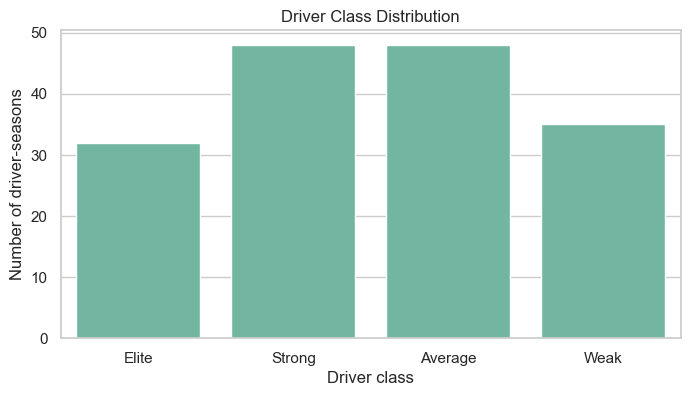

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(data=score_data, x="driver_class", order=class_order)
plt.title("Driver Class Distribution")
plt.xlabel("Driver class")
plt.ylabel("Number of driver-seasons")
plt.show()

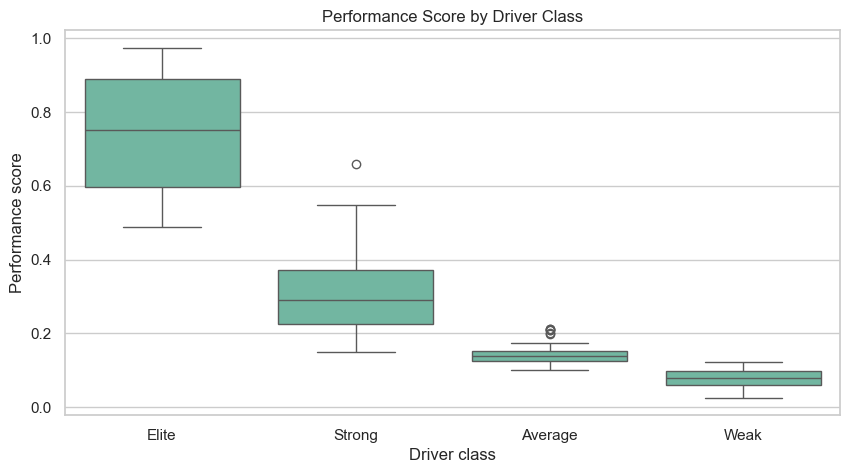

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=score_data,
    x="driver_class",
    y="performance_score",
    order=class_order,
)
plt.title("Performance Score by Driver Class")
plt.xlabel("Driver class")
plt.ylabel("Performance score")
plt.show()


In [21]:
summary_columns = [
    "total_points", "avg_grid_position", "podiums",
    "estimated_overtakes", "points_per_race", "podium_rate"
]
display(score_data.groupby("driver_class")[summary_columns].mean().round(2).reindex(class_order))

,total_points,avg_grid_position,podiums,estimated_overtakes,points_per_race,podium_rate
driver_class,,,,,,
Elite,78.44,3.58,3.38,5.25,15.71,0.68
Strong,27.08,8.60,0.27,8.67,5.48,0.05
Average,5.67,12.56,0.00,9.42,1.28,0.00
Weak,0.34,15.27,0.00,8.17,0.07,0.00


In [22]:
feature_columns = [
    "races",
    "total_points",
    "avg_grid_position",
    "avg_finish_position",
    "podiums",
    "wins",
    "points_finishes",
    "estimated_overtakes",
    "points_per_race",
    "podium_rate",
    "points_finish_rate",
    "overtakes_per_race",
    "qualifying_score",
]

target_column = "driver_class"
latest_season = score_data["season"].max()


In [23]:
train_data = score_data[score_data["season"] < latest_season].copy()
test_data = score_data[score_data["season"] == latest_season].copy()

X_train = train_data[feature_columns]
y_train = train_data[target_column].astype(str)
X_test = test_data[feature_columns]
y_test = test_data[target_column].astype(str)

In [24]:
print(f"Training seasons: {train_data['season'].min()} to {train_data['season'].max()}")
print(f"Test season: {latest_season}")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training seasons: 2018 to 2024
Test season: 2025
Train shape: (143, 13)
Test shape: (20, 13)


In [ ]:
numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_preprocess, feature_columns)],
    remainder="drop",
)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}


In [27]:
results = []
trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        }
    )
    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)

In [ ]:
display(results_df)

,model,accuracy,macro_f1
1,Random Forest,0.9,0.914286
2,Gradient Boosting,0.9,0.914286
0,Logistic Regression,0.8,0.816667


In [29]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

Best model: Random Forest


In [30]:
test_predictions = best_model.predict(X_test)

print(classification_report(y_test, test_predictions, labels=class_order, zero_division=0))


              precision    recall  f1-score   support

       Elite       1.00      1.00      1.00         4
      Strong       1.00      0.67      0.80         6
     Average       0.75      1.00      0.86         6
        Weak       1.00      1.00      1.00         4

    accuracy                           0.90        20
   macro avg       0.94      0.92      0.91        20
weighted avg       0.93      0.90      0.90        20



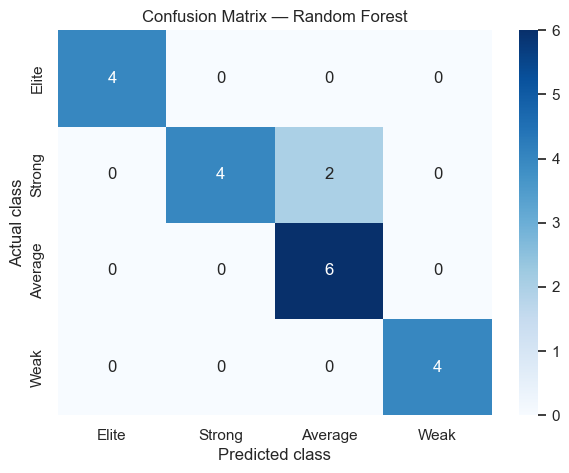

In [31]:
cm = confusion_matrix(y_test, test_predictions, labels=class_order)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()


In [32]:
prediction_table = test_data[[
    "season", "driver", "team", "total_points", "avg_grid_position",
    "podiums", "estimated_overtakes", "performance_score", "driver_class"
]].copy()
prediction_table["predicted_class"] = test_predictions
prediction_table = prediction_table.sort_values("performance_score", ascending=False)

display(prediction_table)


,season,driver,team,total_points,avg_grid_position,podiums,estimated_overtakes,performance_score,driver_class,predicted_class
157,2025,PIA,McLaren,92.0,1.8,4,1.0,0.903704,Elite,Elite
155,2025,NOR,McLaren,88.0,4.4,4,10.0,0.882798,Elite,Elite
162,2025,VER,Red Bull,81.0,3.2,3,2.0,0.780125,Elite,Elite
158,2025,RUS,Mercedes,68.0,3.4,3,2.0,0.706973,Elite,Elite
154,2025,LEC,Ferrari,43.0,4.6,1,1.0,0.452399,Strong,Strong
145,2025,ANT,Mercedes,36.0,8.0,0,14.0,0.370004,Strong,Strong
151,2025,HAM,Ferrari,23.0,7.4,0,5.0,0.273519,Strong,Strong
143,2025,ALB,Williams,20.0,10.2,0,9.0,0.237029,Strong,Strong
156,2025,OCO,Haas F1 Team,14.0,16.2,0,23.0,0.181272,Strong,Average
146,2025,BEA,Haas F1 Team,6.0,16.4,0,27.0,0.150109,Strong,Average


,feature,importance
1,total_points,0.211084
8,points_per_race,0.187797
3,avg_finish_position,0.126183
4,podiums,0.096672
9,podium_rate,0.077735
2,avg_grid_position,0.072628
6,points_finishes,0.066129
12,qualifying_score,0.060959
10,points_finish_rate,0.058106
7,estimated_overtakes,0.018353


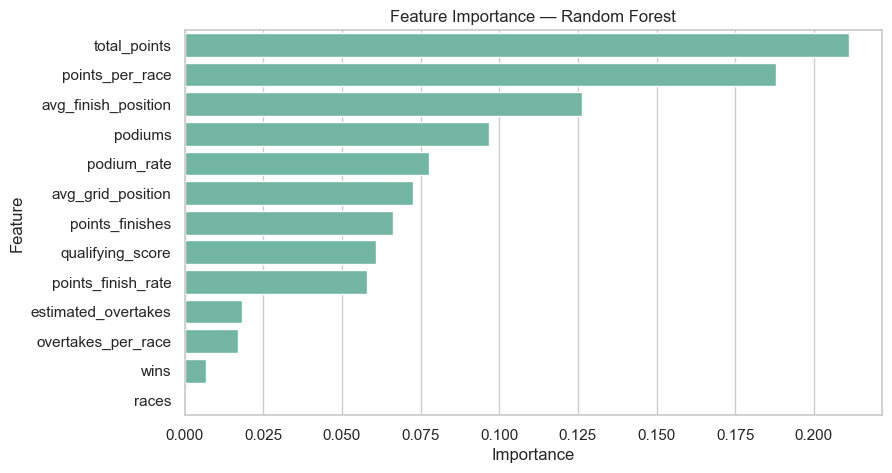

In [33]:
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": model_step.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print(f"{best_model_name} does not expose tree-style feature importance.")


In [34]:
model_path = ARTIFACT_DIR / "module_3_driver_performance_classifier.joblib"
labeled_data_path = ARTIFACT_DIR / "module_3_driver_performance_labeled.csv"
predictions_path = ARTIFACT_DIR / "module_3_driver_performance_predictions.csv"
metrics_path = ARTIFACT_DIR / "module_3_driver_performance_metrics.json"

joblib.dump(
    {
        "model": best_model,
        "feature_columns": feature_columns,
        "class_order": class_order,
        "best_model_name": best_model_name,
    },
    model_path,
)


['artifacts/module_3_driver_performance_classifier.joblib']

In [ ]:
score_data.to_csv(labeled_data_path, index=False)
prediction_table.to_csv(predictions_path, index=False)

In [36]:
metrics = {
    "best_model": best_model_name,
    "test_season": int(latest_season),
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "macro_f1": float(f1_score(y_test, test_predictions, average="macro")),
    "train_rows": int(len(train_data)),
    "test_rows": int(len(test_data)),
}
metrics_path.write_text(json.dumps(metrics, indent=2))

151

In [37]:
print("Saved model to:", model_path)
print("Saved labeled data to:", labeled_data_path)
print("Saved predictions to:", predictions_path)
print("Saved metrics to:", metrics_path)

Saved model to: artifacts/module_3_driver_performance_classifier.joblib
Saved labeled data to: artifacts/module_3_driver_performance_labeled.csv
Saved predictions to: artifacts/module_3_driver_performance_predictions.csv
Saved metrics to: artifacts/module_3_driver_performance_metrics.json


In [38]:
sample_driver = pd.DataFrame([
    {
        "races": 22,
        "total_points": 260,
        "avg_grid_position": 3.8,
        "avg_finish_position": 3.4,
        "podiums": 11,
        "wins": 4,
        "points_finishes": 20,
        "estimated_overtakes": 28,
        "points_per_race": 260 / 22,
        "podium_rate": 11 / 22,
        "points_finish_rate": 20 / 22,
        "overtakes_per_race": 28 / 22,
        "qualifying_score": 17.2,
    }
])


In [39]:
bundle = joblib.load(model_path)
loaded_model = bundle["model"]

predicted_class = loaded_model.predict(sample_driver[bundle["feature_columns"]])[0]
print("Predicted driver class:", predicted_class)


Predicted driver class: Elite
